In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler 


Up untill now I am just downloading the dataset, but in this dataset the index is multi-index so wi first flattened it

In [2]:
# now because csv dont parse the date time so this might be an issue for me, as the data will be trained in the future project based on 
# rolling window approach so it is really crucial to make sure that the data has the datetime sorted 

FinalStocks = pd.read_csv('data/raw_stocks.csv', parse_dates=["Date"])
# this is the first step to clean the data cleaning and making sure that the date column is of type datetime only 

In [3]:
FinalStocks.head(10)

,Date,Close,High,Low,Open,Volume,Ticker
0,2010-01-04,14.224621,14.284055,14.102450,14.115657,4436014,BHP.AX
1,2010-01-05,14.290658,14.409527,14.274149,14.363300,10918398,BHP.AX
2,2010-01-06,14.468966,14.478872,14.376511,14.389720,7806934,BHP.AX
3,2010-01-07,14.452452,14.574623,14.445848,14.498679,7964069,BHP.AX
4,2010-01-08,14.402923,14.485470,14.363299,14.426035,5510642,BHP.AX
5,2010-01-11,14.683585,14.690189,14.505282,14.521792,11048942,BHP.AX
6,2010-01-12,14.359999,14.495377,14.343489,14.478868,10769158,BHP.AX
7,2010-01-13,14.237831,14.277455,14.151982,14.181699,15675825,BHP.AX
8,2010-01-14,14.455756,14.544909,14.317077,14.346793,12295931,BHP.AX
9,2010-01-15,14.412827,14.422733,14.290656,14.386412,16956523,BHP.AX


In [4]:
# Now lets start with Data cleaning, PreProcessing and EDA

FinalStocks.shape

(41090, 7)

In [5]:
FinalStocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41090 entries, 0 to 41089
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    41090 non-null  datetime64[ns]
 1   Close   41090 non-null  float64       
 2   High    41090 non-null  float64       
 3   Low     41090 non-null  float64       
 4   Open    41090 non-null  float64       
 5   Volume  41090 non-null  int64         
 6   Ticker  41090 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 2.2+ MB


In [6]:
FinalStocks.isnull().sum()
#No null values, which means data for the full 16 years is present, for every stock out of the 10 stocks i chose 

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
Ticker    0
dtype: int64

In [7]:
summary = FinalStocks.groupby("Ticker").agg({
    "Date": ["min", "max", "count"]
})

summary.columns = ["Start_Date", "End_Date", "Num_Records"]

print(summary)
# this is done to check what is start data for every ticker and what data will be present, basically looking for any anomaly

       Start_Date   End_Date  Num_Records
Ticker                                   
ANZ.AX 2010-01-04 2026-04-02         4109
BHP.AX 2010-01-04 2026-04-02         4109
CBA.AX 2010-01-04 2026-04-02         4109
CSL.AX 2010-01-04 2026-04-02         4109
MQG.AX 2010-01-04 2026-04-02         4109
NAB.AX 2010-01-04 2026-04-02         4109
TLS.AX 2010-01-04 2026-04-02         4109
WBC.AX 2010-01-04 2026-04-02         4109
WES.AX 2010-01-04 2026-04-02         4109
WOW.AX 2010-01-04 2026-04-02         4109


In [8]:
is_sorted = FinalStocks.groupby("Ticker")["Date"].apply(lambda x: x.is_monotonic_increasing)

print(is_sorted)

Ticker
ANZ.AX    True
BHP.AX    True
CBA.AX    True
CSL.AX    True
MQG.AX    True
NAB.AX    True
TLS.AX    True
WBC.AX    True
WES.AX    True
WOW.AX    True
Name: Date, dtype: bool


In [9]:
FinalStocks['Return'] = FinalStocks.groupby("Ticker")["Close"].pct_change()

In [10]:
FinalStocks.head(10)

,Date,Close,High,Low,Open,Volume,Ticker,Return
0,2010-01-04,14.224621,14.284055,14.102450,14.115657,4436014,BHP.AX,NaN
1,2010-01-05,14.290658,14.409527,14.274149,14.363300,10918398,BHP.AX,0.004642
2,2010-01-06,14.468966,14.478872,14.376511,14.389720,7806934,BHP.AX,0.012477
3,2010-01-07,14.452452,14.574623,14.445848,14.498679,7964069,BHP.AX,-0.001141
4,2010-01-08,14.402923,14.485470,14.363299,14.426035,5510642,BHP.AX,-0.003427
5,2010-01-11,14.683585,14.690189,14.505282,14.521792,11048942,BHP.AX,0.019486
6,2010-01-12,14.359999,14.495377,14.343489,14.478868,10769158,BHP.AX,-0.022037
7,2010-01-13,14.237831,14.277455,14.151982,14.181699,15675825,BHP.AX,-0.008507
8,2010-01-14,14.455756,14.544909,14.317077,14.346793,12295931,BHP.AX,0.015306
9,2010-01-15,14.412827,14.422733,14.290656,14.386412,16956523,BHP.AX,-0.002970


In [11]:
FinalStocks["LogReturn"] = FinalStocks.groupby("Ticker")["Close"].transform(lambda x: np.log(x / x.shift(1)))

In [12]:
FinalStocks.head(10)

,Date,Close,High,Low,Open,Volume,Ticker,Return,LogReturn
0,2010-01-04,14.224621,14.284055,14.102450,14.115657,4436014,BHP.AX,NaN,NaN
1,2010-01-05,14.290658,14.409527,14.274149,14.363300,10918398,BHP.AX,0.004642,0.004632
2,2010-01-06,14.468966,14.478872,14.376511,14.389720,7806934,BHP.AX,0.012477,0.012400
3,2010-01-07,14.452452,14.574623,14.445848,14.498679,7964069,BHP.AX,-0.001141,-0.001142
4,2010-01-08,14.402923,14.485470,14.363299,14.426035,5510642,BHP.AX,-0.003427,-0.003433
5,2010-01-11,14.683585,14.690189,14.505282,14.521792,11048942,BHP.AX,0.019486,0.019299
6,2010-01-12,14.359999,14.495377,14.343489,14.478868,10769158,BHP.AX,-0.022037,-0.022284
7,2010-01-13,14.237831,14.277455,14.151982,14.181699,15675825,BHP.AX,-0.008507,-0.008544
8,2010-01-14,14.455756,14.544909,14.317077,14.346793,12295931,BHP.AX,0.015306,0.015190
9,2010-01-15,14.412827,14.422733,14.290656,14.386412,16956523,BHP.AX,-0.002970,-0.002974


Now i have got the return columns which is really crucial in order to check what will the whole trend will be.

Further more i am adding Technical Indicators which are required for the model to predict as the model cannot see charts but it can see differnt deviation and numbers on the basis of which it can learn how to make sure that the trend is moving

* **SMA** - Simple Moving Average: to predict the upward or the downward trend of the stock
* **Volatility**: To predict the risk and uncertainity of a stock

In [13]:
FinalStocks["SMA_5"] = FinalStocks.groupby("Ticker")["Close"].transform(lambda x: x.rolling(window=5).mean())
FinalStocks["SMA_10"] = FinalStocks.groupby("Ticker")["Close"].transform(lambda x: x.rolling(window=10).mean())
FinalStocks["VOLATILE_5"] = FinalStocks.groupby("Ticker")["Close"].transform(lambda x: x.rolling(window=5).std())
FinalStocks["VOLATILE_10"] = FinalStocks.groupby("Ticker")["Close"].transform(lambda x: x.rolling(window=10).std())

In [14]:
FinalStocks.head(15)

,Date,Close,High,Low,Open,Volume,Ticker,Return,LogReturn,SMA_5,SMA_10,VOLATILE_5,VOLATILE_10
0,2010-01-04,14.224621,14.284055,14.102450,14.115657,4436014,BHP.AX,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-05,14.290658,14.409527,14.274149,14.363300,10918398,BHP.AX,0.004642,0.004632,NaN,NaN,NaN,NaN
2,2010-01-06,14.468966,14.478872,14.376511,14.389720,7806934,BHP.AX,0.012477,0.012400,NaN,NaN,NaN,NaN
3,2010-01-07,14.452452,14.574623,14.445848,14.498679,7964069,BHP.AX,-0.001141,-0.001142,NaN,NaN,NaN,NaN
4,2010-01-08,14.402923,14.485470,14.363299,14.426035,5510642,BHP.AX,-0.003427,-0.003433,14.367924,NaN,0.106166,NaN
5,2010-01-11,14.683585,14.690189,14.505282,14.521792,11048942,BHP.AX,0.019486,0.019299,14.459717,NaN,0.143232,NaN
6,2010-01-12,14.359999,14.495377,14.343489,14.478868,10769158,BHP.AX,-0.022037,-0.022284,14.473585,NaN,0.124963,NaN
7,2010-01-13,14.237831,14.277455,14.151982,14.181699,15675825,BHP.AX,-0.008507,-0.008544,14.427358,NaN,0.163812,NaN
8,2010-01-14,14.455756,14.544909,14.317077,14.346793,12295931,BHP.AX,0.015306,0.015190,14.428019,NaN,0.163945,NaN
9,2010-01-15,14.412827,14.422733,14.290656,14.386412,16956523,BHP.AX,-0.002970,-0.002974,14.430000,14.398962,0.163625,0.134086


In [15]:
FinalStocks["TargetReturn"] = FinalStocks.groupby("Ticker")["Return"].transform(
    lambda x: x.shift(-1)
)

In [16]:
display(FinalStocks[["Date", "Ticker", "Return", "TargetReturn"]].head(10))

,Date,Ticker,Return,TargetReturn
0,2010-01-04,BHP.AX,NaN,0.004642
1,2010-01-05,BHP.AX,0.004642,0.012477
2,2010-01-06,BHP.AX,0.012477,-0.001141
3,2010-01-07,BHP.AX,-0.001141,-0.003427
4,2010-01-08,BHP.AX,-0.003427,0.019486
5,2010-01-11,BHP.AX,0.019486,-0.022037
6,2010-01-12,BHP.AX,-0.022037,-0.008507
7,2010-01-13,BHP.AX,-0.008507,0.015306
8,2010-01-14,BHP.AX,0.015306,-0.002970
9,2010-01-15,BHP.AX,-0.002970,-0.004811


In [17]:
display(FinalStocks[["Date", "Ticker", "Return", "TargetReturn"]].tail(10))

,Date,Ticker,Return,TargetReturn
41080,2026-03-20,TLS.AX,-0.001887,0.001890
41081,2026-03-23,TLS.AX,0.001890,0.007547
41082,2026-03-24,TLS.AX,0.007547,-0.003745
41083,2026-03-25,TLS.AX,-0.003745,-0.001880
41084,2026-03-26,TLS.AX,-0.001880,0.003766
41085,2026-03-27,TLS.AX,0.003766,0.001876
41086,2026-03-30,TLS.AX,0.001876,-0.001873
41087,2026-03-31,TLS.AX,-0.001873,0.001876
41088,2026-04-01,TLS.AX,0.001876,0.014981
41089,2026-04-02,TLS.AX,0.014981,NaN


Now with this feature we are planning to give the target to the model, which is the next day, if todays return is X what will be tommorows return to predict which is lets say Y

now here the ``TargetReturn`` is the regression target and ``TargetTrend`` is classification target

In [18]:
FinalStocks["TargetTrend"] =(FinalStocks["TargetReturn"] > 0).astype(int)

In [19]:
FinalStocks.head(10)

,Date,Close,High,Low,Open,Volume,Ticker,Return,LogReturn,SMA_5,SMA_10,VOLATILE_5,VOLATILE_10,TargetReturn,TargetTrend
0,2010-01-04,14.224621,14.284055,14.102450,14.115657,4436014,BHP.AX,NaN,NaN,NaN,NaN,NaN,NaN,0.004642,1
1,2010-01-05,14.290658,14.409527,14.274149,14.363300,10918398,BHP.AX,0.004642,0.004632,NaN,NaN,NaN,NaN,0.012477,1
2,2010-01-06,14.468966,14.478872,14.376511,14.389720,7806934,BHP.AX,0.012477,0.012400,NaN,NaN,NaN,NaN,-0.001141,0
3,2010-01-07,14.452452,14.574623,14.445848,14.498679,7964069,BHP.AX,-0.001141,-0.001142,NaN,NaN,NaN,NaN,-0.003427,0
4,2010-01-08,14.402923,14.485470,14.363299,14.426035,5510642,BHP.AX,-0.003427,-0.003433,14.367924,NaN,0.106166,NaN,0.019486,1
5,2010-01-11,14.683585,14.690189,14.505282,14.521792,11048942,BHP.AX,0.019486,0.019299,14.459717,NaN,0.143232,NaN,-0.022037,0
6,2010-01-12,14.359999,14.495377,14.343489,14.478868,10769158,BHP.AX,-0.022037,-0.022284,14.473585,NaN,0.124963,NaN,-0.008507,0
7,2010-01-13,14.237831,14.277455,14.151982,14.181699,15675825,BHP.AX,-0.008507,-0.008544,14.427358,NaN,0.163812,NaN,0.015306,1
8,2010-01-14,14.455756,14.544909,14.317077,14.346793,12295931,BHP.AX,0.015306,0.015190,14.428019,NaN,0.163945,NaN,-0.002970,0
9,2010-01-15,14.412827,14.422733,14.290656,14.386412,16956523,BHP.AX,-0.002970,-0.002974,14.430000,14.398962,0.163625,0.134086,-0.004811,0


So now lets clarify what I am planning to do here, this is the universal dataset which I am making this data will be loaded into the ML models for time t to predict t+1 then this will be loaded into the LSTM with rolling window concept of 30 days to predict next day, after which I will add the macro economic data along with the sentiment into my core Hybrid Model.

In [20]:
print(FinalStocks["TargetReturn"].describe())

count    41080.000000
mean         0.000485
std          0.013881
min         -0.168878
25%         -0.006476
50%          0.000552
75%          0.007713
max          0.132619
Name: TargetReturn, dtype: float64


In [21]:
print(FinalStocks["TargetTrend"].value_counts())
print()
print(FinalStocks["TargetTrend"].value_counts(normalize=True))

TargetTrend
1    21110
0    19980
Name: count, dtype: int64

TargetTrend
1    0.51375
0    0.48625
Name: proportion, dtype: float64


In [22]:
FinalStocks.shape

(41090, 15)

In [23]:
FinalStocks.isnull().sum()

Date             0
Close            0
High             0
Low              0
Open             0
Volume           0
Ticker           0
Return          10
LogReturn       10
SMA_5           40
SMA_10          90
VOLATILE_5      40
VOLATILE_10     90
TargetReturn    10
TargetTrend      0
dtype: int64

In [24]:
FinalStocks = FinalStocks.dropna().reset_index(drop=True)

In [25]:
FinalStocks.isnull().sum()

Date            0
Close           0
High            0
Low             0
Open            0
Volume          0
Ticker          0
Return          0
LogReturn       0
SMA_5           0
SMA_10          0
VOLATILE_5      0
VOLATILE_10     0
TargetReturn    0
TargetTrend     0
dtype: int64

In [26]:
FinalStocks.shape

(40990, 15)

In [27]:
FinalStocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40990 entries, 0 to 40989
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          40990 non-null  datetime64[ns]
 1   Close         40990 non-null  float64       
 2   High          40990 non-null  float64       
 3   Low           40990 non-null  float64       
 4   Open          40990 non-null  float64       
 5   Volume        40990 non-null  int64         
 6   Ticker        40990 non-null  object        
 7   Return        40990 non-null  float64       
 8   LogReturn     40990 non-null  float64       
 9   SMA_5         40990 non-null  float64       
 10  SMA_10        40990 non-null  float64       
 11  VOLATILE_5    40990 non-null  float64       
 12  VOLATILE_10   40990 non-null  float64       
 13  TargetReturn  40990 non-null  float64       
 14  TargetTrend   40990 non-null  int64         
dtypes: datetime64[ns](1), float64(11), i

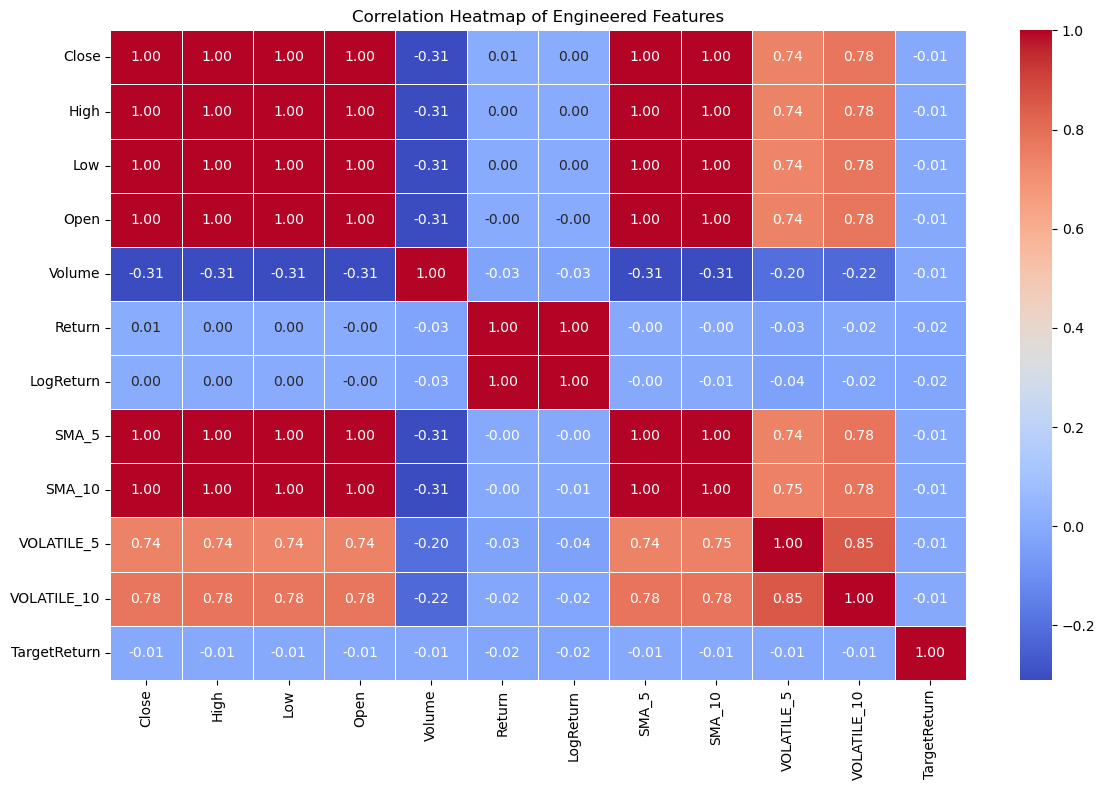

In [28]:
correlation_Columns = [
    'Close', 'High', 'Low', 'Open', 'Volume',
    'Return', 'LogReturn',
    'SMA_5', 'SMA_10',
    'VOLATILE_5', 'VOLATILE_10',
    'TargetReturn'
]

FinalMatrix = FinalStocks[correlation_Columns].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(FinalMatrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Engineered Features")
plt.tight_layout()
plt.show()

In [29]:
FinalStocks = FinalStocks.sort_values(by=['Ticker', 'Date']).reset_index(drop=True)

# =========================================================
# ADDING NEW ENGINEERED FEATURES
# =========================================================

# Lagged returns
FinalStocks['Return_lag1'] = FinalStocks.groupby('Ticker')['Return'].shift(1)
FinalStocks['Return_lag2'] = FinalStocks.groupby('Ticker')['Return'].shift(2)
FinalStocks['Return_lag3'] = FinalStocks.groupby('Ticker')['Return'].shift(3)
FinalStocks['Return_lag5'] = FinalStocks.groupby('Ticker')['Return'].shift(5)

FinalStocks['Momentum_5'] = FinalStocks.groupby('Ticker')['Return'].rolling(5).sum().reset_index(level=0, drop=True)
FinalStocks['Momentum_10'] = FinalStocks.groupby('Ticker')['Return'].rolling(10).sum().reset_index(level=0, drop=True)
FinalStocks['Return_mean_5'] = FinalStocks.groupby('Ticker')['Return'].rolling(5).mean().reset_index(level=0, drop=True)
FinalStocks['Return_mean_10'] = FinalStocks.groupby('Ticker')['Return'].rolling(10).mean().reset_index(level=0, drop=True)
FinalStocks['Return_std_5'] = FinalStocks.groupby('Ticker')['Return'].rolling(5).std().reset_index(level=0, drop=True)
FinalStocks['Return_std_10'] = FinalStocks.groupby('Ticker')['Return'].rolling(10).std().reset_index(level=0, drop=True)

# Lagged volatility
FinalStocks['Vol_lag1'] = FinalStocks.groupby('Ticker')['VOLATILE_5'].shift(1)
FinalStocks['Vol_lag2'] = FinalStocks.groupby('Ticker')['VOLATILE_5'].shift(2)

# Relative price vs moving averages
FinalStocks['Close_SMA5_diff'] = FinalStocks['Close'] - FinalStocks['SMA_5']
FinalStocks['Close_SMA10_diff'] = FinalStocks['Close'] - FinalStocks['SMA_10']

# =========================================================
# DROPING ROWS WITH NaNs CREATED BY LAGS / ROLLING FEATURES
# =========================================================
FinalStocks = FinalStocks.dropna().reset_index(drop=True)

# =========================================================
# RE-SORTING FOR CLEAN PANEL STRUCTURE
# =========================================================
FinalStocks = FinalStocks.sort_values(by=['Date', 'Ticker']).reset_index(drop=True)

# =========================================================
# DEFINING FINAL FEATURE COLUMNS FOR BETTER RESULTS THIS TIME
# =========================================================
feature_columns = [
    'Close',
    'Return',
    'SMA_5',
    'SMA_10',
    'VOLATILE_5',
    'VOLATILE_10',
    'Volume',
    'Return_lag1',
    'Return_lag2',
    'Return_lag3',
    'Return_lag5',
    'Vol_lag1',
    'Vol_lag2',
    'Close_SMA5_diff',
    'Close_SMA10_diff',
    'Momentum_5',
    'Momentum_10',
    'Return_mean_5',
    'Return_mean_10',
    'Return_std_5',
    'Return_std_10'

]

# =========================================================
# DATE SPLIT BOUNDARIES
# =========================================================
TrainingEnd = '2021-12-31'
ValidationEnd = '2023-12-31'

# =========================================================
# TIME-BASED SPLIT
# =========================================================
training_data = FinalStocks[FinalStocks['Date'] <= TrainingEnd]
validation_data = FinalStocks[
    (FinalStocks['Date'] > TrainingEnd) & (FinalStocks['Date'] <= ValidationEnd)
]
testing_data = FinalStocks[FinalStocks['Date'] > ValidationEnd]

# =========================================================
# SEPARATE FEATURES (X) AND TARGETS (y)
# =========================================================

# Features
X_train = training_data[feature_columns]
X_validation = validation_data[feature_columns]
X_test = testing_data[feature_columns]

# Regression targets
y_train_regression = training_data['TargetReturn']
y_validation_regression = validation_data['TargetReturn']
y_test_regression = testing_data['TargetReturn']

# Classification targets
y_train_classification = training_data['TargetTrend']
y_validation_classification = validation_data['TargetTrend']
y_test_classification = testing_data['TargetTrend']

# =========================================================
# CHECKING FOR SPLIT SHAPES AND DATE RANGES
# =========================================================
print("Train:", X_train.shape)
print("Validation:", X_validation.shape)
print("Test:", X_test.shape)

print(training_data['Date'].min(), training_data['Date'].max())
print(validation_data['Date'].min(), validation_data['Date'].max())
print(testing_data['Date'].min(), testing_data['Date'].max())

# =========================================================
# SCALING FEATURES ONLY FOR TRAIN
# =========================================================
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_validation)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_validation.columns, index=X_validation.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


Train: (30170, 21)
Validation: (5030, 21)
Test: (5700, 21)
2010-01-29 00:00:00 2021-12-31 00:00:00
2022-01-04 00:00:00 2023-12-29 00:00:00
2024-01-02 00:00:00 2026-04-01 00:00:00


since now, I am done with the scaling and also the whole data pre-processing and figured out the columns to make sure that they are not highly corealted in order to make sure the model don't over fit, so now I will use the ML models without the ticker values and see what kind of performance am i getting.

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


In [31]:
Lr = LinearRegression()

In [32]:
Lr.fit(X_train_scaled, y_train_regression)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
Vaidation_Predict_Reg = Lr.predict(X_val_scaled)

In [34]:
Test_Predict_Reg = Lr.predict(X_test_scaled)

In [35]:
# Validation metrics
val_mae = mean_absolute_error(y_validation_regression, Vaidation_Predict_Reg)
val_rmse = np.sqrt(mean_squared_error(y_validation_regression, Vaidation_Predict_Reg))
val_r2 = r2_score(y_validation_regression, Vaidation_Predict_Reg)

# Test metrics
test_mae = mean_absolute_error(y_test_regression, Test_Predict_Reg)
test_rmse = np.sqrt(mean_squared_error(y_test_regression, Test_Predict_Reg))
test_r2 = r2_score(y_test_regression, Test_Predict_Reg)

print("Linear Regression - Validation")
print("MAE :", round(val_mae, 4))
print("RMSE:", round(val_rmse, 4))
print("R²  :", round(val_r2, 4))

print("\nLinear Regression - Test")
print("MAE :", round(test_mae, 4))
print("RMSE:", round(test_rmse, 4))
print("R²  :", round(test_r2, 4))

Linear Regression - Validation
MAE : 0.0095
RMSE: 0.013
R²  : -0.0167

Linear Regression - Test
MAE : 0.0093
RMSE: 0.0134
R²  : -0.0207


These results prove that my engineered features have very poor predictive power, which was expected so, we will move further with other models

In [36]:
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,              # ← LIMIT DEPTH
    min_samples_leaf=50,      # ← REDUCE OVERFITTING
    random_state=42,
    n_jobs=-1
)

In [37]:
random_forest_model.fit(X_train_scaled, y_train_regression)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",50
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [38]:
val_prediction_rf = random_forest_model.predict(X_val_scaled)
test_prediction_rf = random_forest_model.predict(X_test_scaled)

In [39]:
# Validation
val_mae_rf = mean_absolute_error(y_validation_regression, val_prediction_rf)
val_rmse_rf = np.sqrt(mean_squared_error(y_validation_regression, val_prediction_rf))
val_r2_rf = r2_score(y_validation_regression, val_prediction_rf)

# Test
test_mae_rf = mean_absolute_error(y_test_regression, test_prediction_rf)
test_rmse_rf = np.sqrt(mean_squared_error(y_test_regression, test_prediction_rf))
test_r2_rf = r2_score(y_test_regression, test_prediction_rf)

print("Random Forest - Validation")
print("MAE :", round(val_mae_rf, 4))
print("RMSE:", round(val_rmse_rf, 4))
print("R²  :", round(val_r2_rf, 4))

print("\nRandom Forest - Test")
print("MAE :", round(test_mae_rf, 4))
print("RMSE:", round(test_rmse_rf, 4))
print("R²  :", round(test_r2_rf, 4))

Random Forest - Validation
MAE : 0.0095
RMSE: 0.0129
R²  : -0.0079

Random Forest - Test
MAE : 0.0093
RMSE: 0.0134
R²  : -0.0199


In [40]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    n_jobs=-1
)

In [41]:
xgb_model.fit(X_train_scaled, y_train_regression)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [42]:
validation_pred_xgb = xgb_model.predict(X_val_scaled)
test_pred_xgb = xgb_model.predict(X_test_scaled)

In [43]:
# Validation
val_mae_rf = mean_absolute_error(y_validation_regression, validation_pred_xgb)
val_rmse_rf = np.sqrt(mean_squared_error(y_validation_regression, validation_pred_xgb))
val_r2_rf = r2_score(y_validation_regression, validation_pred_xgb)

# Test
test_mae_rf = mean_absolute_error(y_test_regression, test_pred_xgb)
test_rmse_rf = np.sqrt(mean_squared_error(y_test_regression, test_pred_xgb))
test_r2_rf = r2_score(y_test_regression, test_pred_xgb)

print("XGB - Validation")
print("MAE :", round(val_mae_rf, 4))
print("RMSE:", round(val_rmse_rf, 4))
print("R²  :", round(val_r2_rf, 4))

print("\nXGB - Test")
print("MAE :", round(test_mae_rf, 4))
print("RMSE:", round(test_rmse_rf, 4))
print("R²  :", round(test_r2_rf, 4))

XGB - Validation
MAE : 0.0095
RMSE: 0.0129
R²  : -0.008

XGB - Test
MAE : 0.0093
RMSE: 0.0134
R²  : -0.0254
